# Options Pricing & Implied Volatility — guided walkthrough

A from-scratch Black-Scholes implementation, a Newton-Raphson/Brent implied-vol
solver, and real option-chain data collected by an automated snapshot pipeline
(`run_pipeline.py`, cron-scheduled at US market open/midday/close).

This notebook works from the **snapshot archive** in `data/snapshots/` — the
immutable, timestamped pulls the pipeline collects — so it runs without
hitting the market data API (except the earnings-date lookup at the end).
Run from the repo root or `notebooks/`; the first cell fixes the path.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))  # repo root when run from notebooks/

import numpy as np
import pandas as pd
from IPython.display import Image, display

from src.black_scholes import bs_price, delta, gamma, vega, theta
from src.implied_vol import implied_vol, solve_chain
from src.data_fetch import load_snapshots, filter_liquid
from src.plotting import (plot_smile, plot_term_structure, pick_smile_expiry,
                          atm_iv_by_expiry, atm_iv_history, plot_atm_history)

## 1. Black-Scholes from scratch

The price of a European call is `S·e^{-qT}·N(d1) − K·e^{-rT}·N(d2)`: the
expected present value of receiving the stock conditional on exercise, minus
the PV of paying the strike times the risk-neutral probability of exercise.
Sanity-check against the standard textbook case (full suite:
`python -m src.test_black_scholes`, 14 checks including finite-difference
verification of every Greek).

In [2]:
S, K, T, r, sigma = 100.0, 100.0, 1.0, 0.05, 0.20   # ATM, 1y, 20% vol

print(f"call  = {bs_price(S, K, T, r, sigma, option_type='call'):.4f}   (textbook: 10.4506)")
print(f"put   = {bs_price(S, K, T, r, sigma, option_type='put'):.4f}    (textbook:  5.5735)")
print(f"delta = {delta(S, K, T, r, sigma):.4f}, gamma = {gamma(S, K, T, r, sigma):.4f}, "
      f"vega = {vega(S, K, T, r, sigma):.2f}, theta = {theta(S, K, T, r, sigma):.2f}/yr")

c = bs_price(S, K, T, r, sigma, option_type='call')
p = bs_price(S, K, T, r, sigma, option_type='put')
print(f"put-call parity residual = {c - p - (S - K*np.exp(-r*T)):.2e}")

call  = 10.4506   (textbook: 10.4506)
put   = 5.5735    (textbook:  5.5735)
delta = 0.6368, gamma = 0.0188, vega = 37.52, theta = -6.41/yr
put-call parity residual = 0.00e+00


## 2. Implied vol: Newton-Raphson with a Brent fallback

Vega > 0 makes price monotone in vol, so a unique implied vol exists whenever
the price sits inside the no-arbitrage bounds. Newton (analytic vega,
Brenner-Subrahmanyam seed) converges quadratically where vega is healthy;
where it's tiny — deep ITM/OTM, near expiry — the Newton step explodes and
Brent takes over. Prices outside the bounds get `None`, never a forced
number: the failure rate is a data-quality diagnostic.

In [3]:
p_known = bs_price(100, 100, 1.0, 0.05, 0.20)
iv, method = implied_vol(p_known, 100, 100, 1.0, 0.05)
print(f"round trip ATM:      true 0.20 -> {iv:.12f} via {method}")

p_otm = bs_price(100, 150, 0.5, 0.05, 0.35)
iv2, method2 = implied_vol(p_otm, 100, 150, 0.5, 0.05)
print(f"round trip deep OTM: true 0.35 -> {iv2:.12f} via {method2}")

bad, m = implied_vol(0.5, 100, 90, 0.5, 0.05, 0.0, 'call')   # below intrinsic
print(f"below-intrinsic quote -> iv={bad}, method={m}  (refused, not forced)")

round trip ATM:      true 0.20 -> 0.200000000000 via newton
round trip deep OTM: true 0.35 -> 0.350000000000 via brent
below-intrinsic quote -> iv=None, method=None  (refused, not forced)


## 3. Real market data from the snapshot archive

`load_snapshots` combines every immutable pull in `data/snapshots/` into one
pull-time-indexed DataFrame; each snapshot carries its own spot, risk-free
rate, dividend yield, and a stale-quotes flag from its JSON sidecar. We solve
the latest snapshot. Note the price-source distinction: market-hours pulls
use bid/ask midpoints; overnight pulls fall back to prior-session lastPrice
(Yahoo clears quotes overnight) with T anchored to that session's close.

In [4]:
combined = load_snapshots("SPY")
latest_time = combined.index.max()
latest = combined[combined.index == latest_time].reset_index(drop=True)
spot = float(latest["spot"].iloc[0])
stale = bool(latest["stale_quotes"].iloc[0])
print(f"latest snapshot: {latest_time:%Y-%m-%d %H:%M %Z}, spot {spot:.2f}, "
      f"{'stale lastPrice quotes' if stale else 'live bid/ask midpoints'}")

liquid, fdiag = filter_liquid(latest, stale)
solved, sdiag = solve_chain(liquid, spot, latest["r"].iloc[0], latest["q"].iloc[0])

  loaded 22 snapshot(s) for SPY: 2026-07-09 01:24 -> 2026-07-17 15:45 NY, 65032 contract rows
latest snapshot: 2026-07-17 15:45 UTC-04:00, spot 743.54, live bid/ask midpoints
  liquidity filter [live/mid]: 2896 -> kept 2114 (73%); dropped: 395 zero_bid, 0 no_ask, 387 spread>20%


  IV solver: 2114 contracts -> 1202 Newton (56.9%), 594 Brent fallback (28.1%), 318 failed (15.0%)


Failures should cluster where theory says implied vol genuinely doesn't
exist — quotes below intrinsic value in the deep wings:

In [5]:
failed = solved[solved["iv_method"] == "failed"].copy()
intrinsic = np.where(failed["option_type"] == "call",
                     np.maximum(spot - failed["strike"], 0),
                     np.maximum(failed["strike"] - spot, 0))
print(f"{len(failed)} failed of {len(solved)} "
      f"({len(failed)/len(solved):.1%}); {(failed['price'] < intrinsic).sum()} "
      "are quotes below intrinsic value (no IV exists)")
print("\nfailures by expiry:")
print(failed.groupby(failed["expiry"].dt.date).size().to_string())

318 failed of 2114 (15.0%); 200 are quotes below intrinsic value (no IV exists)

failures by expiry:
expiry
2026-07-17    175
2026-07-20     26
2026-07-21     11
2026-07-22      4
2026-07-23      5
2026-07-24     54
2026-07-28      2
2026-07-31     41


## 4. The volatility smile

Two views of the same expiry (re-picked each run as the expiry nearest 30
days *from the snapshot's timestamp* — the same anchor as every T in the
solves). The full chart includes ITM contracts, whose intrinsic-heavy prices
make IV hypersensitive to quote noise — that's where calls and puts diverge.
The OTM chart keeps puts below spot and calls above (desk convention): the
side of each wing where the vol information actually lives.

smile expiry: 2026-08-14 (nearest 30d from snapshot 2026-07-17)


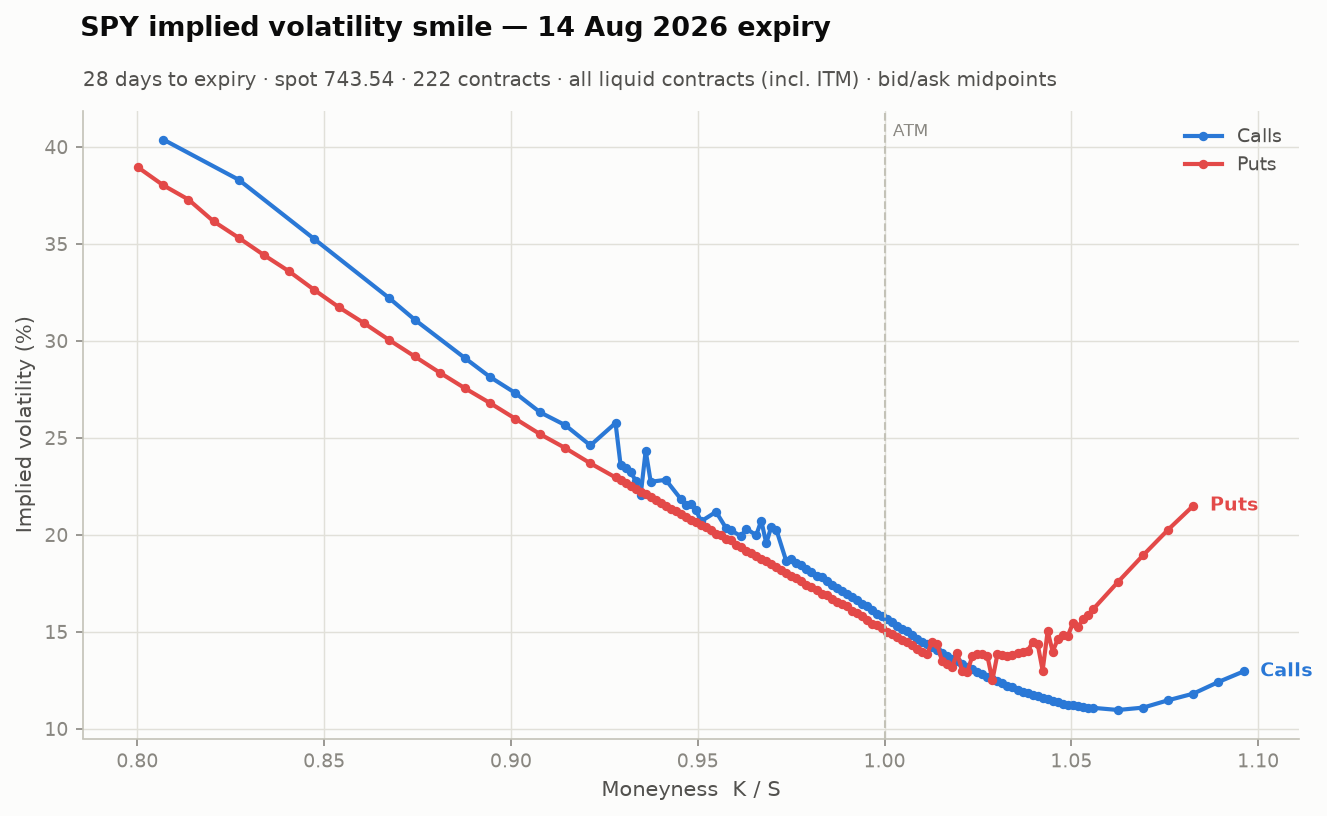

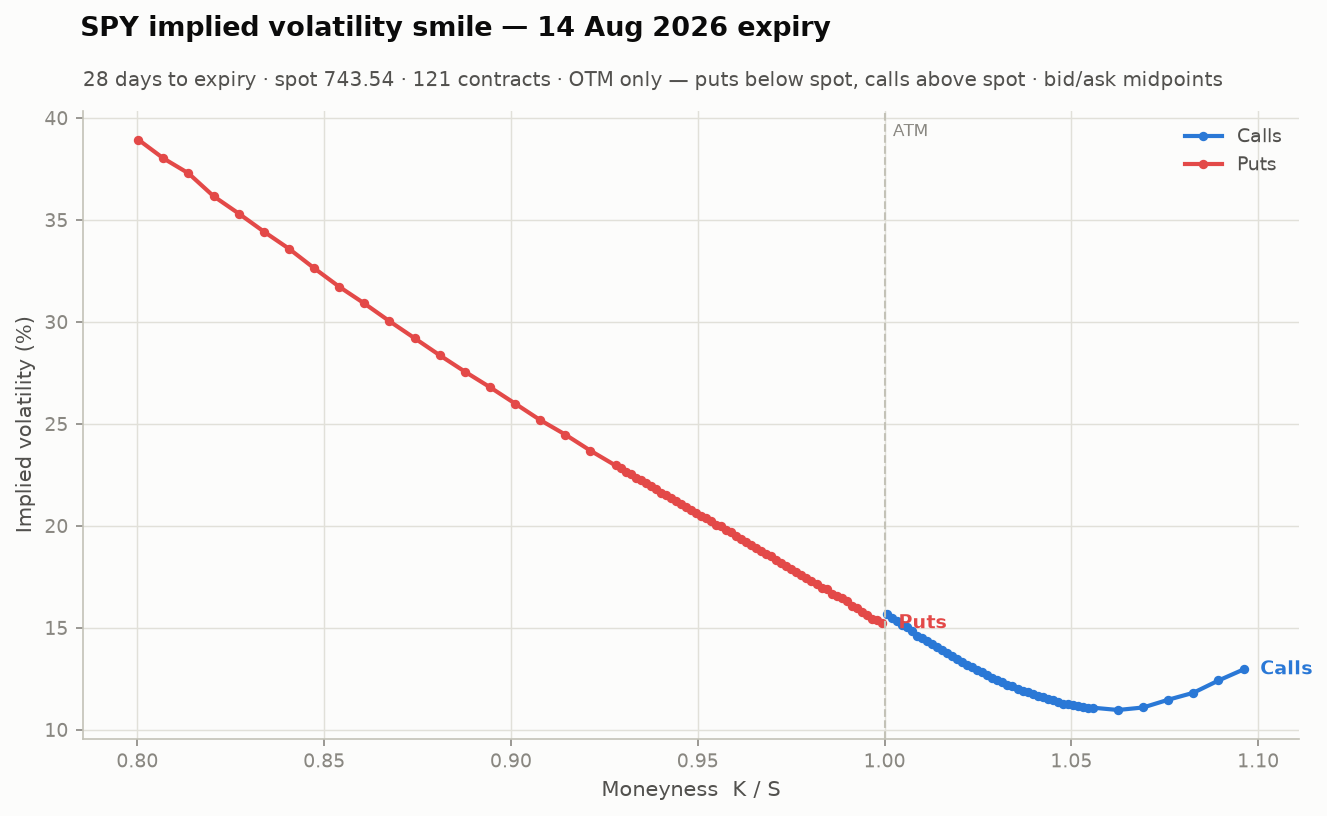

In [6]:
exp = pick_smile_expiry(solved)
print(f"smile expiry: {exp:%Y-%m-%d} (nearest 30d from snapshot {latest_time:%Y-%m-%d})")
# same args as run_pipeline.py, so the notebook regenerates identical charts
note = "lastPrice data (overnight pull)" if stale else "bid/ask midpoints"
p1 = plot_smile(solved, spot, exp, "smile_SPY.png", note=note, ticker="SPY")
p2 = plot_smile(solved, spot, exp, "smile_otm_SPY.png", note=note,
                otm_only=True, ticker="SPY")
display(Image(str(p1)), Image(str(p2)))

Why the skew: crash risk has been priced into index options since October
1987 (fat left tail), the leverage effect makes low-price states genuinely
higher-vol states, and institutions systematically buy index puts as
insurance. Under Black-Scholes assumptions this line would be flat.

## 5. ATM term structure

Implied vol interpolated at K = spot for every expiry. Upward-sloping
(contango) is the calm-market norm; a downward slope (backwardation) means
the market prices more near-term than long-term vol — an event on the
calendar or a vol spike expected to mean-revert. The check below reads the
shape off the current numbers rather than assuming it.

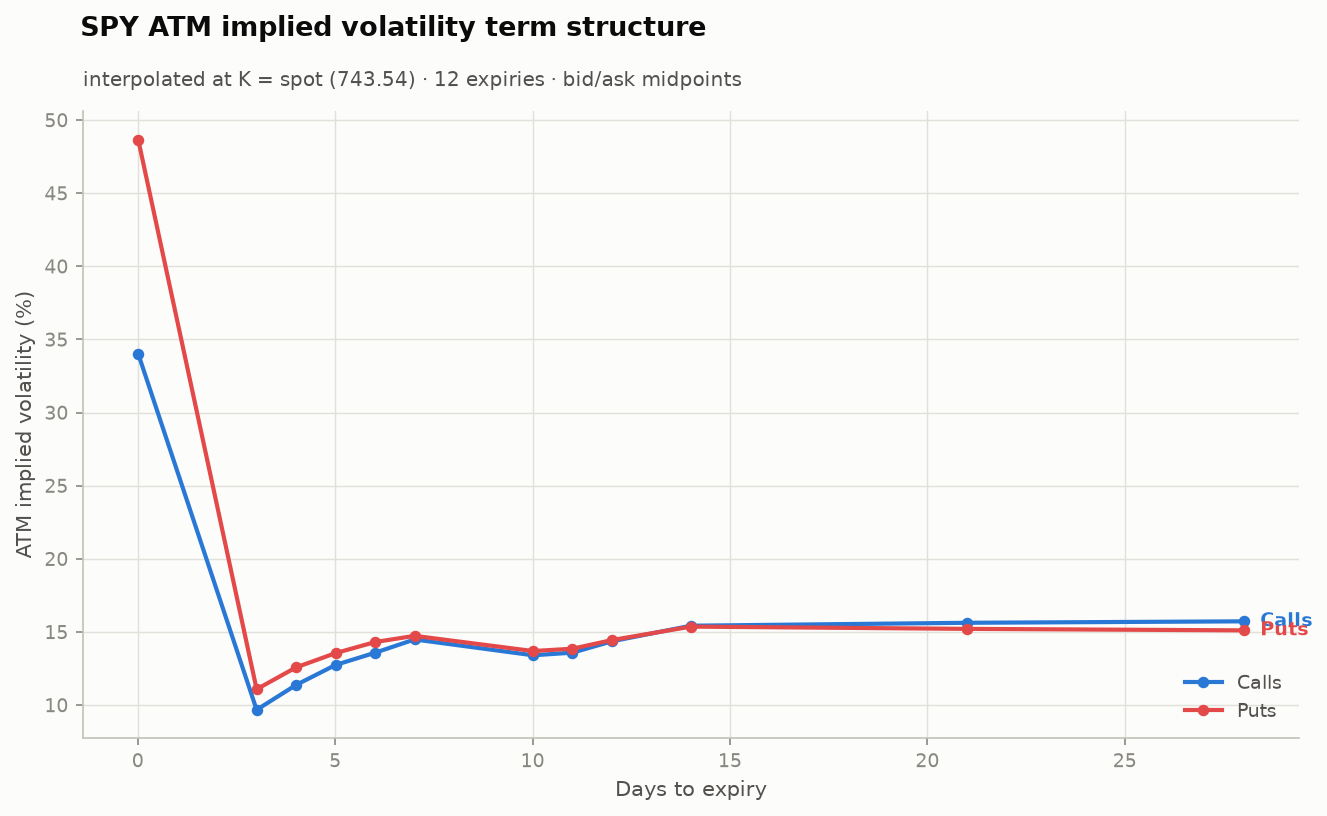

ATM vol <=1wk: 18.2%   >=20d: 15.4%   -> backwardation (downward)


In [7]:
p3, atm = plot_term_structure(solved, spot, out_name="term_structure_SPY.png",
                              note=note, ticker="SPY")
display(Image(str(p3)))
atm_short = atm[atm["T_days"] <= 7]["atm_iv"].mean()
atm_1m = atm[atm["T_days"] >= 20]["atm_iv"].mean()
shape = ("contango (upward)" if atm_1m > atm_short + 0.003 else
         "backwardation (downward)" if atm_short > atm_1m + 0.003 else "flat")
print(f"ATM vol <=1wk: {atm_short:.1%}   >=20d: {atm_1m:.1%}   -> {shape}")

## 6. The smile over time — constant-maturity ATM history

The pipeline's accumulating chart: for every archived snapshot, solve the ATM
neighborhood and interpolate IV at fixed 7- and 30-day tenors (constant
maturity, like the VIX's 30-day interpolation — so the series doesn't jump
when the front expiry rolls off). Stale overnight snapshots are flagged in
the chart subtitle.

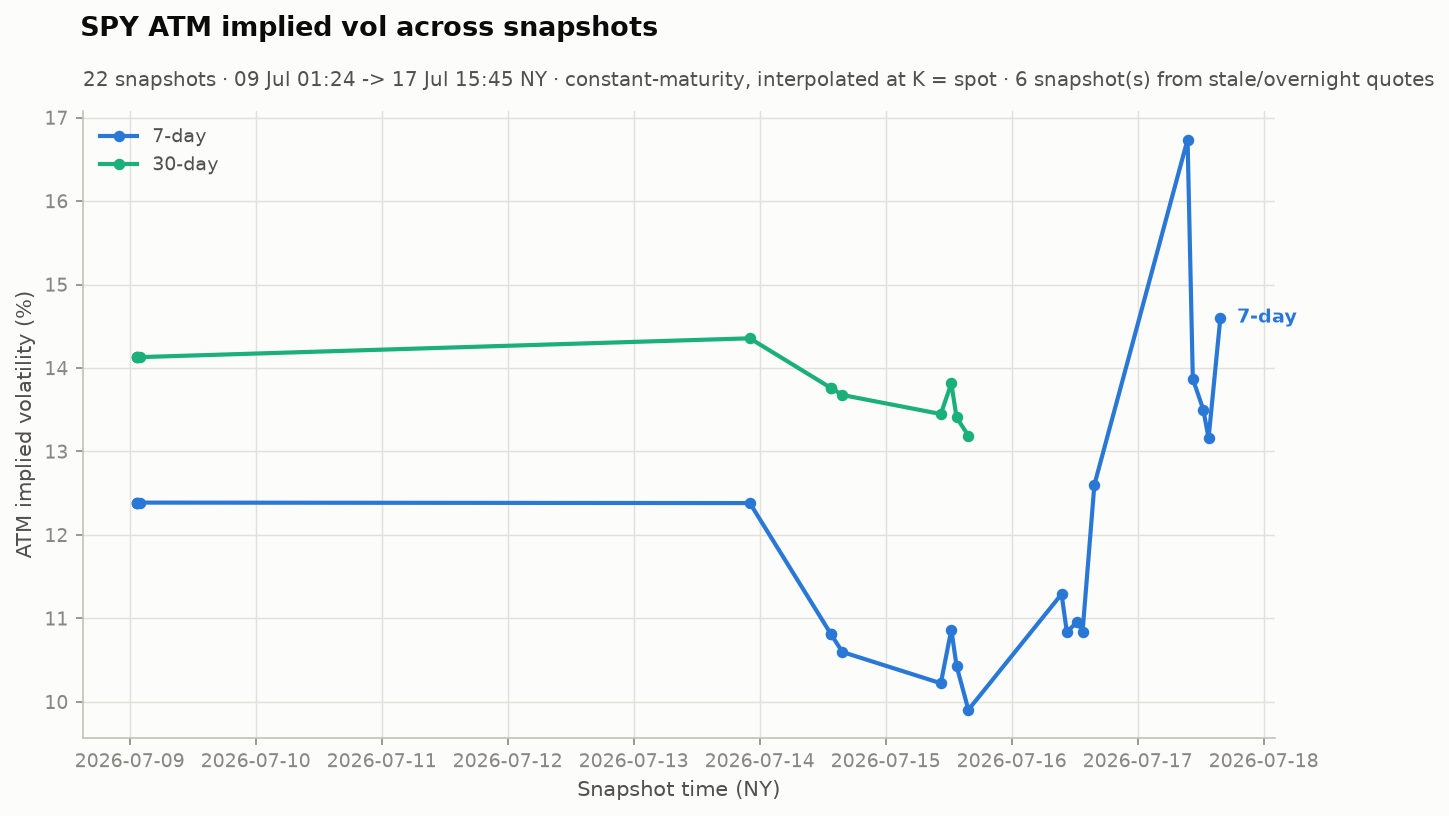

                                        spot  stale_quotes     7d  30d
pull_time                                                             
2026-07-17 09:30:17.379772-04:00  742.450012          True  16.74  NaN
2026-07-17 10:30:12.305279-04:00  746.520020         False  13.87  NaN
2026-07-17 12:30:12.127947-04:00  746.070007         False  13.50  NaN
2026-07-17 13:30:12.112628-04:00  746.895020         False  13.16  NaN
2026-07-17 15:45:12.153993-04:00  743.539978         False  14.60  NaN


In [8]:
hist = atm_iv_history(combined, tenors=(7, 30))
p4 = plot_atm_history(hist, out_name="atm_history_SPY.png", ticker="SPY")
display(Image(str(p4)))
print(hist.tail(5).assign(**{c: (hist[c]*100).round(2) for c in ('7d','30d')})
      [["spot", "stale_quotes", "7d", "30d"]].to_string())

## 7. Earnings vol: premium, implied move, and the crush

The pipeline tracks earnings through a lifecycle: full analysis when a report
is within 60 days (or 3 days after, to capture the crush), each run archiving
its numbers to `data/earnings_archive_NFLX.json`; outside that window the
chart becomes an explicit status view over the archived event. The July 2026
NFLX event was captured end-to-end by the scheduled snapshots:

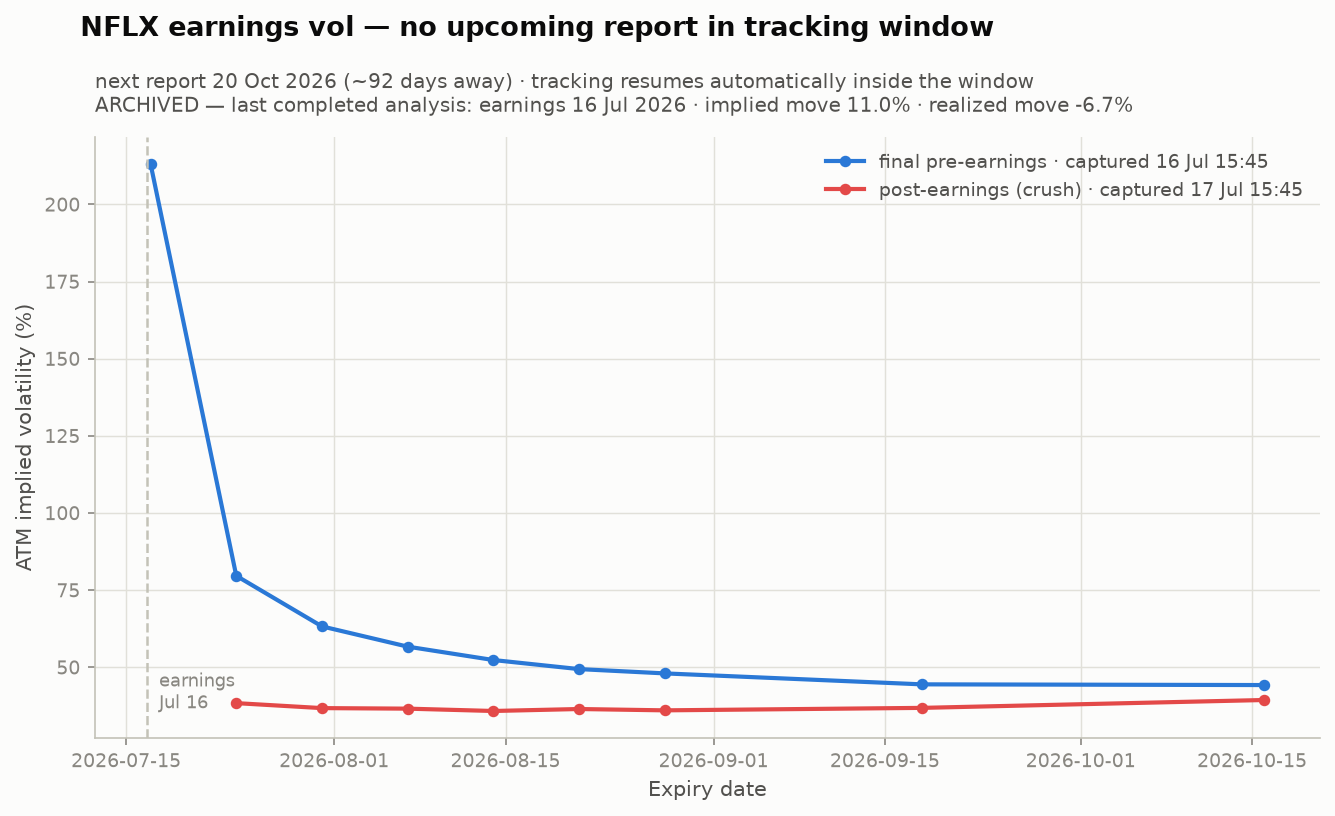

archived event: 2026-07-16
  final pre-print capture: front-expiry ATM IV 213%, implied move 11.0%
  post-print capture:      front-expiry ATM IV 38% (the crush)
  realized move -6.7% vs 11.0% implied -> the market overpaid for the event (the vol-seller's edge)
next report: 2026-10-20


In [9]:
from src.earnings_vol import earnings_dates_around_now, load_earnings_archive

prev_e, next_e = earnings_dates_around_now("NFLX")
arch = load_earnings_archive("NFLX")
display(Image(str(pathlib.Path.cwd().parent / "outputs" / "earnings_NFLX.png")))

if arch and arch.get("captures"):
    pre, post = arch["captures"].get("pre"), arch["captures"].get("post")
    print(f"archived event: {pd.Timestamp(arch['event']):%Y-%m-%d}")
    if pre:
        print(f"  final pre-print capture: front-expiry ATM IV "
              f"{pre['curve'][0]['atm_iv']:.0%}, implied move {pre['implied_move']:.1%}")
    if post:
        print(f"  post-print capture:      front-expiry ATM IV "
              f"{post['curve'][0]['atm_iv']:.0%} (the crush)")
    if pre and post:
        print(f"  realized move {post['spot']/pre['spot']-1:+.1%} "
              f"vs {pre['implied_move']:.1%} implied -> the market overpaid "
              "for the event (the vol-seller's edge)")
print(f"next report: {next_e:%Y-%m-%d}" if next_e is not None else "next report unknown")

## Where this all runs automatically

- `run_pipeline.py` — per ticker: immutable snapshot -> IV solve ->
  accumulating history chart -> replacing smile/term-structure/earnings
  charts -> README auto-sections (marker-delimited, with conditional prose
  that adapts to what the data shows). Every stage is failure-isolated and
  logged to `logs/pipeline.log`.
- Cron fires it at US market open / midday / near close on weekdays (with a
  market-hours guard, so off-hours firings just refresh charts).
- `README.md` is therefore a living document: its results table and analysis
  paragraphs describe the *current* data, not the day the project was
  written.